In [1]:
import os
import glob
import cv2
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tqdm import tqdm

# CONFIG - adjust to your setup
DATA_REAL = r"C:\DeepFake Detection\data\real"
DATA_FAKE = r"C:\DeepFake Detection\data\fake"
PREPROCESSED_DIR = r"C:\DeepFake Detection\data\preprocessed"

IMG_SIZE = 64
MAX_FRAMES = 10
BATCH_SIZE = 32  # Increased from 2 to 32
RANDOM_SEED = 42

tf.random.set_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

# Enable GPU memory growth to avoid OOM errors
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"Found {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(e)
else:
    print("No GPU found - using CPU")

# Enable mixed precision for faster training
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')
print("Mixed precision enabled")

print("Configuration loaded successfully")

Found 1 GPU(s)
INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4060 Ti, compute capability 8.9
Mixed precision enabled
Configuration loaded successfully


In [2]:
def load_video_frames(video_path, max_frames=MAX_FRAMES, img_size=IMG_SIZE):
    """
    Load and preprocess video frames.
    This will be run ONCE to create preprocessed .npy files.
    """
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        cap.release()
        return np.zeros((max_frames, img_size, img_size, 3), dtype=np.float32)
    
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT) or 0)
    
    if total <= 0:
        # Fallback: read sequentially
        frames = []
        while True:
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
            frames.append(frame)
        cap.release()
        
        if len(frames) == 0:
            return np.zeros((max_frames, img_size, img_size, 3), dtype=np.float32)
        
        if len(frames) >= max_frames:
            frames = frames[:max_frames]
        else:
            # Pad with last frame
            last = frames[-1]
            while len(frames) < max_frames:
                frames.append(last)
        
        arr = np.stack(frames, axis=0).astype(np.float32) / 255.0
        return arr
    
    # Uniform sampling
    indices = np.linspace(0, total - 1, num=max_frames, dtype=np.int32)
    frames = []
    
    for idx in indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
        ret, frame = cap.read()
        if not ret or frame is None:
            if len(frames) > 0:
                frame = frames[-1]
            else:
                frame = np.zeros((img_size, img_size, 3), dtype=np.uint8)
        else:
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            frame = cv2.resize(frame, (img_size, img_size))
        frames.append(frame)
    
    cap.release()
    arr = np.stack(frames, axis=0).astype(np.float32) / 255.0
    return arr


def preprocess_all_videos(real_dir, fake_dir, output_dir, max_frames=MAX_FRAMES, img_size=IMG_SIZE):
    """
    Preprocess all videos and save as .npy files.
    RUN THIS ONCE before training.
    """
    os.makedirs(output_dir, exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'real'), exist_ok=True)
    os.makedirs(os.path.join(output_dir, 'fake'), exist_ok=True)
    
    # Get all video paths
    real_paths = sorted(
        glob.glob(os.path.join(real_dir, "*.mp4")) + 
        glob.glob(os.path.join(real_dir, "*.avi"))
    )
    fake_paths = sorted(
        glob.glob(os.path.join(fake_dir, "*.mp4")) + 
        glob.glob(os.path.join(fake_dir, "*.avi"))
    )[:4000]
    
    print(f"Found {len(real_paths)} real videos and {len(fake_paths)} fake videos")
    
    # Process real videos
    print("Processing REAL videos...")
    for video_path in tqdm(real_paths):
        frames = load_video_frames(video_path, max_frames, img_size)
        filename = os.path.basename(video_path).replace('.mp4', '').replace('.avi', '') + '.npy'
        output_path = os.path.join(output_dir, 'real', filename)
        np.save(output_path, frames)
    
    # Process fake videos
    print("Processing FAKE videos...")
    for video_path in tqdm(fake_paths):
        frames = load_video_frames(video_path, max_frames, img_size)
        filename = os.path.basename(video_path).replace('.mp4', '').replace('.avi', '') + '.npy'
        output_path = os.path.join(output_dir, 'fake', filename)
        np.save(output_path, frames)
    
    print(f"Preprocessing complete! Files saved to {output_dir}")
    return len(real_paths), len(fake_paths)

In [3]:
# Check if preprocessing is needed
if not os.path.exists(PREPROCESSED_DIR) or len(os.listdir(PREPROCESSED_DIR)) < 2:
    print("Starting preprocessing... This may take a while but only needs to run once.")
    num_real, num_fake = preprocess_all_videos(DATA_REAL, DATA_FAKE, PREPROCESSED_DIR)
    print(f"Preprocessed {num_real} real and {num_fake} fake videos")
else:
    print("Preprocessed data already exists. Skipping preprocessing.")
    print(f"If you want to reprocess, delete the folder: {PREPROCESSED_DIR}")

Starting preprocessing... This may take a while but only needs to run once.
Found 1890 real videos and 4000 fake videos
Processing REAL videos...


100%|██████████████████████████████████████████████████████████████████████████████| 1890/1890 [11:46<00:00,  2.67it/s]


Processing FAKE videos...


100%|██████████████████████████████████████████████████████████████████████████████| 4000/4000 [03:00<00:00, 22.21it/s]

Preprocessing complete! Files saved to C:\DeepFake Detection\data\preprocessed
Preprocessed 1890 real and 4000 fake videos


In [4]:
@tf.function
def tf_augment_video(video):
    """
    Apply augmentations using TensorFlow operations.
    These run on GPU and are much faster than Albumentations.
    video shape: (MAX_FRAMES, IMG_SIZE, IMG_SIZE, 3)
    """
    # Random horizontal flip (50% chance)
    if tf.random.uniform(()) > 0.5:
        video = tf.image.flip_left_right(video)
    
    # Random brightness (50% chance)
    if tf.random.uniform(()) > 0.5:
        video = tf.image.random_brightness(video, max_delta=0.2)
    
    # Random contrast (50% chance)
    if tf.random.uniform(()) > 0.5:
        video = tf.image.random_contrast(video, lower=0.8, upper=1.2)
    
    # Random hue (40% chance)
    if tf.random.uniform(()) > 0.6:
        video = tf.image.random_hue(video, max_delta=0.1)
    
    # Random saturation (40% chance)
    if tf.random.uniform(()) > 0.6:
        video = tf.image.random_saturation(video, lower=0.8, upper=1.2)
    
    # Add Gaussian noise (30% chance)
    if tf.random.uniform(()) > 0.7:
        noise = tf.random.normal(tf.shape(video), mean=0.0, stddev=0.02)
        video = video + noise
    
    # JPEG compression simulation (40% chance) - approximate with quantization
    if tf.random.uniform(()) > 0.6:
        quality_factor = tf.random.uniform((), minval=0.7, maxval=1.0)
        video = tf.round(video * 255.0 * quality_factor) / (255.0 * quality_factor)
    
    # Clip values to [0, 1]
    video = tf.clip_by_value(video, 0.0, 1.0)
    
    return video

In [5]:
# ============================================================================
# CELL 5: Dataset Loading Functions
# ============================================================================
def load_preprocessed_numpy(path_tensor, label_tensor):
    """
    Load preprocessed .npy file.
    Much faster than loading video on-the-fly.
    """
    def _load_npy(path):
        if isinstance(path, bytes):
            path = path.decode('utf-8')
        elif hasattr(path, 'numpy'):
            path = path.numpy().decode('utf-8')
        data = np.load(path).astype(np.float32)
        return data
    
    video = tf.py_function(func=_load_npy, inp=[path_tensor], Tout=tf.float32)
    video.set_shape([MAX_FRAMES, IMG_SIZE, IMG_SIZE, 3])
    label = tf.cast(label_tensor, tf.float32)
    
    return video, label


def build_optimized_dataset(preprocessed_dir, batch_size=BATCH_SIZE, val_split=0.15, test_split=0.15):
    """
    Build dataset from preprocessed .npy files with GPU-accelerated augmentation.
    """
    # Get preprocessed file paths
    real_paths = sorted(glob.glob(os.path.join(preprocessed_dir, 'real', '*.npy')))
    fake_paths = sorted(glob.glob(os.path.join(preprocessed_dir, 'fake', '*.npy')))
    
    print(f"Found preprocessed files - real: {len(real_paths)}, fake: {len(fake_paths)}")
    
    paths = real_paths + fake_paths
    labels = [0] * len(real_paths) + [1] * len(fake_paths)
    
    # Stratified splits
    paths_trainval, paths_test, y_trainval, y_test = train_test_split(
        paths, labels, test_size=test_split, random_state=RANDOM_SEED, stratify=labels
    )
    paths_train, paths_val, y_train, y_val = train_test_split(
        paths_trainval, y_trainval, 
        test_size=val_split/(1.0-test_split), 
        random_state=RANDOM_SEED, 
        stratify=y_trainval
    )
    
    print(f"Train: {len(paths_train)}, Val: {len(paths_val)}, Test: {len(paths_test)}")
    
    def make_dataset(p_list, y_list, train=False, shuffle=True):
        ds = tf.data.Dataset.from_tensor_slices((p_list, y_list))
        
        if shuffle:
            ds = ds.shuffle(buffer_size=len(p_list), seed=RANDOM_SEED, reshuffle_each_iteration=True)
        
        # Load preprocessed data
        ds = ds.map(load_preprocessed_numpy, num_parallel_calls=tf.data.AUTOTUNE)
        
        # Apply augmentation for training (GPU-accelerated)
        if train:
            ds = ds.map(
                lambda x, y: (tf_augment_video(x), y), 
                num_parallel_calls=tf.data.AUTOTUNE
            )
        
        # Batch and prefetch
        ds = ds.batch(batch_size, drop_remainder=train)
        ds = ds.prefetch(tf.data.AUTOTUNE)
        
        return ds
    
    train_ds = make_dataset(paths_train, y_train, train=True, shuffle=True)
    val_ds = make_dataset(paths_val, y_val, train=False, shuffle=False)
    test_ds = make_dataset(paths_test, y_test, train=False, shuffle=False)
    
    return train_ds, val_ds, test_ds

In [6]:
# ============================================================================
# CELL 6: Build Datasets
# ============================================================================
train_ds, val_ds, test_ds = build_optimized_dataset(PREPROCESSED_DIR, batch_size=BATCH_SIZE)

# Compute class weights
num_real = len(glob.glob(os.path.join(PREPROCESSED_DIR, 'real', '*.npy')))
num_fake = len(glob.glob(os.path.join(PREPROCESSED_DIR, 'fake', '*.npy')))
total = num_real + num_fake

weight_real = total / (2 * num_real)
weight_fake = total / (2 * num_fake)
class_weights = {0: weight_real, 1: weight_fake}

print(f"Class weights: {class_weights}")


Found preprocessed files - real: 1890, fake: 4000
Train: 4122, Val: 884, Test: 884
Class weights: {0: 1.5582010582010581, 1: 0.73625}


In [7]:
# ============================================================================
# CELL 7: Sanity Check - Verify Data Pipeline
# ============================================================================
print("Testing data pipeline...")
for x_batch, y_batch in train_ds.take(1):
    print(f"Batch video shape: {x_batch.shape}")  # Should be (BATCH_SIZE, MAX_FRAMES, IMG_SIZE, IMG_SIZE, 3)
    print(f"Batch labels shape: {y_batch.shape}")
    print(f"Video dtype: {x_batch.dtype}")
    print(f"Video value range: [{tf.reduce_min(x_batch):.3f}, {tf.reduce_max(x_batch):.3f}]")
    print(f"Labels: {y_batch.numpy()}")
    break

print("Data pipeline looks good!")

Testing data pipeline...
Batch video shape: (32, 10, 64, 64, 3)
Batch labels shape: (32,)
Video dtype: <dtype: 'float32'>
Video value range: [0.000, 1.000]
Labels: [1. 1. 1. 1. 1. 0. 1. 1. 1. 1. 0. 1. 1. 0. 0. 1. 1. 0. 0. 0. 1. 0. 1. 1.
 0. 1. 0. 0. 1. 0. 1. 0.]
Data pipeline looks good!


In [15]:
# ============================================================================
# CELL 8: Build Optimized Model
# ============================================================================
from tensorflow.keras import layers, models

SEQ_LEN = MAX_FRAMES

# Frame-level CNN (MobileNetV2 backbone)
backbone = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)
backbone.trainable = False  # Freeze for initial training

# Build video model
video_input = layers.Input(shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE, 3))

# Apply MobileNet to each frame
x = layers.TimeDistributed(backbone)(video_input)

# Reduce dimension
x = layers.TimeDistributed(layers.Dense(256, activation="relu"))(x)

# Temporal modeling with GRU (faster than LSTM)
x = layers.Bidirectional(
    layers.GRU(128, return_sequences=False, dropout=0.3, recurrent_dropout=0.2)
)(x)

x = layers.Dropout(0.4)(x)

# Output layer (use float32 for final layer in mixed precision)
output = layers.Dense(1, activation="sigmoid", dtype='float32')(x)

model = models.Model(video_input, output)

# Compile with optimizer
optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.compile(
    optimizer=optimizer,
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_4 (InputLayer)        [(None, 10, 64, 64, 3)]   0         
                                                                 
 time_distributed_2 (TimeDis  (None, 10, 1280)         2257984   
 tributed)                                                       
                                                                 
 time_distributed_3 (TimeDis  (None, 10, 256)          327936    
 tributed)                                                       
                                                                 
 bidirectional_1 (Bidirectio  (None, 256)              296448    
 nal)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                           

In [16]:
# ============================================================================
# CELL 9: Training with Callbacks
# ============================================================================
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Create callbacks
callbacks = [
    EarlyStopping(
        monitor='val_auc',
        patience=5,
        mode='max',
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-7,
        verbose=1
    ),
    ModelCheckpoint(
        'best_model.keras',
        monitor='val_auc',
        mode='max',
        save_best_only=True,
        verbose=1
    )
]

print("Starting training...")
print(f"Batch size: {BATCH_SIZE}")
print(f"Using GPU: {len(tf.config.list_physical_devices('GPU')) > 0}")

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

print("Training complete!")

Starting training...
Batch size: 32
Using GPU: True
Epoch 1/20
128/128 [==============================] - ETA: 0s - loss: 0.6245 - accuracy: 0.6516 - auc: 0.7092
Epoch 1: val_auc improved from -inf to 0.81730, saving model to best_model.keras
128/128 [==============================] - 26s 172ms/step - loss: 0.6245 - accuracy: 0.6516 - auc: 0.7092 - val_loss: 0.4831 - val_accuracy: 0.7749 - val_auc: 0.8173 - lr: 1.0000e-04
Epoch 2/20
128/128 [==============================] - ETA: 0s - loss: 0.5539 - accuracy: 0.7239 - auc: 0.7882
Epoch 2: val_auc improved from 0.81730 to 0.85101, saving model to best_model.keras
128/128 [==============================] - 21s 164ms/step - loss: 0.5539 - accuracy: 0.7239 - auc: 0.7882 - val_loss: 0.4433 - val_accuracy: 0.8167 - val_auc: 0.8510 - lr: 1.0000e-04
Epoch 3/20
128/128 [==============================] - ETA: 0s - loss: 0.5099 - accuracy: 0.7673 - auc: 0.8258
Epoch 3: val_auc improved from 0.85101 to 0.86827, saving model to best_model.keras
128

In [17]:
# ============================================================================
# CELL 10: Evaluate Model
# ============================================================================
print("Evaluating on test set...")
test_results = model.evaluate(test_ds, verbose=1)
print(f"\nTest Loss: {test_results[0]:.4f}")
print(f"Test Accuracy: {test_results[1]:.4f}")
print(f"Test AUC: {test_results[2]:.4f}")

Evaluating on test set...
28/28 [==============================] - 4s 113ms/step - loss: 0.3736 - accuracy: 0.8857 - auc: 0.8567

Test Loss: 0.3736
Test Accuracy: 0.8857
Test AUC: 0.8567


In [18]:
# ============================================================================
# CELL 11: Detailed Predictions and Metrics
# ============================================================================
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import pandas as pd

print("Generating predictions...")
y_true = []
y_pred_prob = []

for x_batch, y_batch in tqdm(test_ds):
    preds = model.predict(x_batch, verbose=0).ravel()
    y_true.extend(y_batch.numpy().tolist())
    y_pred_prob.extend(preds.tolist())

y_pred_class = [1 if p > 0.5 else 0 for p in y_pred_prob]

# Metrics
print("\n" + "="*50)
print("CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_true, y_pred_class, target_names=['Real', 'Fake']))

print("\n" + "="*50)
print("CONFUSION MATRIX")
print("="*50)
cm = confusion_matrix(y_true, y_pred_class)
print(f"True Negatives:  {cm[0][0]}")
print(f"False Positives: {cm[0][1]}")
print(f"False Negatives: {cm[1][0]}")
print(f"True Positives:  {cm[1][1]}")

print("\n" + "="*50)
print("ROC AUC SCORE")
print("="*50)
roc_auc = roc_auc_score(y_true, y_pred_prob)
print(f"ROC AUC: {roc_auc:.4f}")

# Create results dataframe
df_results = pd.DataFrame({
    'Actual': y_true,
    'Predicted': y_pred_class,
    'Probability': y_pred_prob
})

print("\n" + "="*50)
print("SAMPLE PREDICTIONS")
print("="*50)
print(df_results.head(20))

# Save results
df_results.to_csv('test_predictions.csv', index=False)
print("\nResults saved to 'test_predictions.csv'")


Generating predictions...


100%|██████████████████████████████████████████████████████████████████████████████████| 28/28 [00:06<00:00,  4.17it/s]


CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Real       0.90      0.72      0.80       284
        Fake       0.88      0.96      0.92       600

    accuracy                           0.89       884
   macro avg       0.89      0.84      0.86       884
weighted avg       0.89      0.89      0.88       884


CONFUSION MATRIX
True Negatives:  205
False Positives: 79
False Negatives: 22
True Positives:  578

ROC AUC SCORE
ROC AUC: 0.8566

SAMPLE PREDICTIONS
    Actual  Predicted  Probability
0      0.0          0     0.258289
1      0.0          0     0.014090
2      0.0          0     0.003886
3      1.0          1     0.983426
4      1.0          1     0.877474
5      1.0          1     0.932826
6      1.0          1     0.847964
7      1.0          1     0.954107
8      0.0          0     0.003221
9      1.0          1     0.901685
10     1.0          1     0.982781
11     1.0          1     0.611248
12     1.0          1     0.912912
13     1.

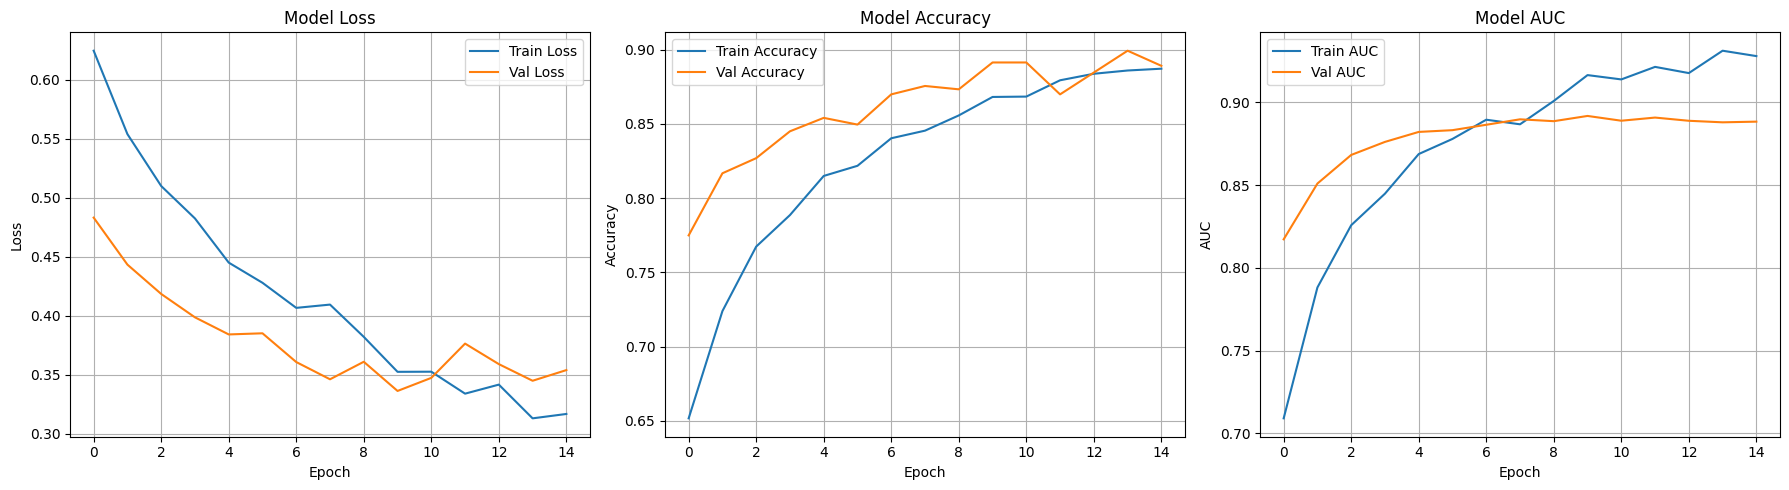

Training history plot saved to 'training_history.png'


In [19]:

# ============================================================================
# CELL 12: Plot Training History
# ============================================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot loss
axes[0].plot(history.history['loss'], label='Train Loss')
axes[0].plot(history.history['val_loss'], label='Val Loss')
axes[0].set_title('Model Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True)

# Plot accuracy
axes[1].plot(history.history['accuracy'], label='Train Accuracy')
axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
axes[1].set_title('Model Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True)

# Plot AUC
axes[2].plot(history.history['auc'], label='Train AUC')
axes[2].plot(history.history['val_auc'], label='Val AUC')
axes[2].set_title('Model AUC')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.savefig('training_history.png', dpi=300, bbox_inches='tight')
plt.show()

print("Training history plot saved to 'training_history.png'")

In [20]:
model.save("df_detection_model_v2.h5")


In [ ]:
# ============================================================================
# CELL 13: (OPTIONAL) Fine-tune Model - Unfreeze Backbone
# ============================================================================
# print("="*50)
# print("OPTIONAL: Fine-tuning with unfrozen backbone")
# print("="*50)
# print("Uncomment and run this cell if you want to fine-tune the model")
# print("This will unfreeze the MobileNet backbone for better performance")

"""
# Unfreeze the backbone
backbone.trainable = True

# Recompile with lower learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),  # Lower LR for fine-tuning
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")]
)

# Fine-tune for a few more epochs
history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5,
    class_weight=class_weights,
    callbacks=callbacks,
    verbose=1
)

# Re-evaluate
test_results_finetuned = model.evaluate(test_ds, verbose=1)
print(f"\nFine-tuned Test Loss: {test_results_finetuned[0]:.4f}")
print(f"Fine-tuned Test Accuracy: {test_results_finetuned[1]:.4f}")
print(f"Fine-tuned Test AUC: {test_results_finetuned[2]:.4f}")
"""